<a href="https://colab.research.google.com/github/elhamod/BA305_Fall_2026/blob/main/Session%2010%20-%20MAKEUP%20FRI%20OCT%202%20-%20EXAM%201%20PREP/exam1_practice_auto_mpg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exam 1 Practice: Auto MPG**

You work for a used-car website. Sellers often leave fields blank on the listing form. The team has three questions:

1. Can we **shorten the form**?
2. Can we **estimate a missing mpg**?
3. Can we **tag a car "Imported" or "Domestic"** automatically?

**Practice, not graded.** Use Colab's AI for the code. Write the one-sentence answers yourself: on the exam you read output, you don't run code.

| Part | Topic | Time |
| --- | --- | --- |
| 1 | Cleaning and charts | ~15 min |
| 2 | Fewer dimensions | ~13 min |
| 3 | Regression | ~16 min |
| 4 | Classification | ~26 min |

**Data:** Auto MPG, 398 cars from 1970–1982.

## Setup

In [25]:
# Import the libraries this notebook uses.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [26]:
# Load the Auto MPG data: one row per car model.
cars = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv')
cars.head()

#drop name?  Too specific and hard to separate brand

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


# **Part 1: Know your data** (~15 min)

### Clean the data

**Exercise 1.** Look at every column. Decide which ones a model can use as they are, which need fixing, and which should be dropped. Then clean the data.

In [43]:
cars2 = cars.drop(columns = ['name'],axis = 1)
cars2["imported"] = False
cars2.loc[cars["origin"] != "usa", "imported"] = True
cars2

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,imported
0,18.0,8,307.0,130.0,3504,12.0,70,usa,False
1,15.0,8,350.0,165.0,3693,11.5,70,usa,False
2,18.0,8,318.0,150.0,3436,11.0,70,usa,False
3,16.0,8,304.0,150.0,3433,12.0,70,usa,False
4,17.0,8,302.0,140.0,3449,10.5,70,usa,False
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,False
394,44.0,4,97.0,52.0,2130,24.6,82,europe,True
395,32.0,4,135.0,84.0,2295,11.6,82,usa,False
396,28.0,4,120.0,79.0,2625,18.6,82,usa,False


**Question 1.** Which columns did you keep, fix or drop, and why? How many cars are left?

cars.drop(columns = ["name"])
#name is hard to filter by

*Provide your answer here*

### Check a claim

Sales says: *"Imported cars get better mileage."*

**Exercise 2.**
1. Compare the average mpg of imported and domestic cars. Does it back the claim?
2. Weight also affects mileage. Plot mpg against weight, colored by origin. Then compare the average mpg by origin for light cars only (under 2,500 lb).

In [42]:

cars2.groupby("imported")["mpg"].mean()

,mpg
imported,
False,20.083534
True,29.248322


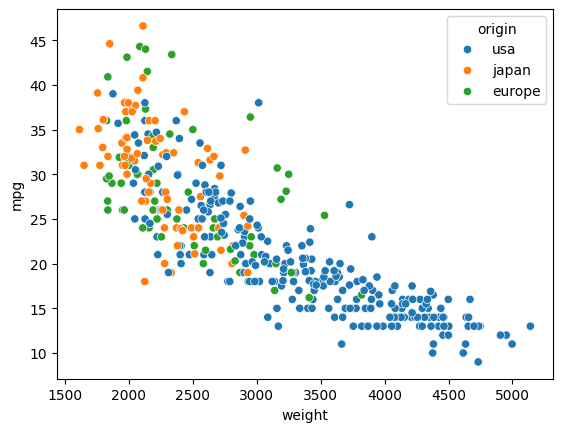

In [52]:
cars2.groupby("origin")[["weight","mpg"]].mean()
sns.scatterplot(data=cars2, x='weight', y='mpg',hue = 'origin');


**Question 2.** Is being imported the real cause of better mileage, or is it something else? What does the relationship with weight suggest?

**Answer**
#No, it seems to be that lower weight has a greater mpg
*Provide your answer here*

# **Part 2: Do we need all six specs?** (~13 min)

The form asks for six specs: cylinders, displacement, horsepower, weight, acceleration and mpg. If some say the same thing, we can ask for fewer.

In [54]:
# The six specs the listing form asks for.
specs = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'mpg']

### How much repeats?

**Exercise 3.** Look at how the six specs relate to each other. Then find a way to describe each car with fewer numbers while losing as little information as possible.

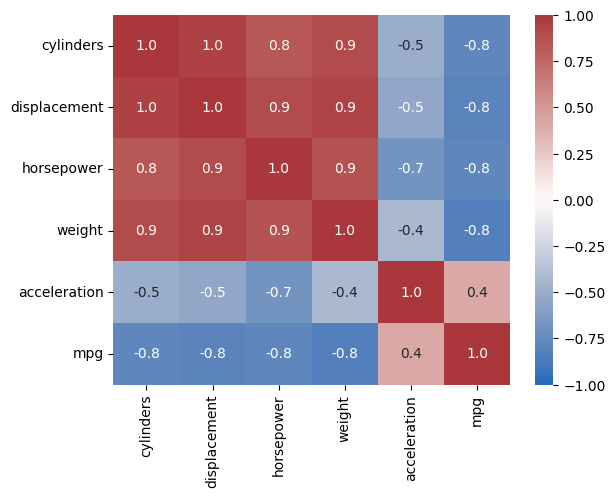

In [57]:
metric = cars2[specs]
metrics_corr = metric.corr()
sns.heatmap(metrics_corr, annot=True, fmt=".1f", vmin=-1, vmax=1, cmap='vlag');

In [60]:
spread = metric.agg(['min', 'max', 'mean', 'std']).T.sort_values('std', ascending=False)
print('most variable column is', round(spread['std'].max() / spread['std'].min()),
      'times more spread out than the least')
spread.round(1)
# scaler = StandardScaler()
# scaled_df = pd.DataFrame(scaler.fit_transform(metric), columns=metric.columns)
# scaled_df.head()

most variable column is 498 times more spread out than the least


,min,max,mean,std
weight,1613.0,5140.0,2970.4,846.8
displacement,68.0,455.0,193.4,104.3
horsepower,46.0,230.0,104.5,38.5
mpg,9.0,46.6,23.5,7.8
acceleration,8.0,24.8,15.6,2.8
cylinders,3.0,8.0,5.5,1.7


**Question 3.** Which specs move together? How many new dimensions do you need to keep about 85% of the variation?

**Answer**

*Provide your answer here*

### What are the ideas?

**Exercise 4.** Interpret the new dimensions: what does each of the first three measure?

In [ ]:
# Your code here

**Question 4.** Give each of the first three new dimensions a plain-English name. Which original specs drive each one?

**Answer**

*Provide your answer here*

# **Part 3: Estimate mpg** (~16 min)

Many listings have no mpg. We want to show an estimate, but only if it is close enough.

### How far off is the estimate?

**Exercise 5.** Predict mpg from the other five specs and origin. Compute the test RMSE of two approaches: an average guess and linear regression. Then compute R² for each.

In [ ]:
# Your code here

**Question 5.** Finish the sentence: *"A typical estimate is off by about ___ mpg."* What does R² tell you that RMSE does not?

**Answer**

*Provide your answer here*

### Can we trust that number?

**Exercise 6.** Estimate linear regression's RMSE with 5-fold cross-validation.

In [ ]:
# Your code here

**Question 6.** How much does the RMSE change from fold to fold? Which number would you quote to the team, and why?

**Answer**

*Provide your answer here*

# **Part 4: Tag imports** (~26 min)

Buyers filter by "Imported". If an import is tagged "Domestic", those buyers never see it. Can the specs predict the tag?

### Better than guessing?

**Exercise 7.** Find the share of imported cars. Then choose k for kNN with cross-validation.

*New tool:* `make_pipeline(StandardScaler(), model)` scales inside each fold, so the test fold never leaks into the scaling.

In [ ]:
# Your code here

**Question 7.** How accurate is calling every car "Domestic"? Which k do you pick, and how much better than that baseline is kNN?

**Answer**

*Provide your answer here*

### Precision vs. recall

The code below is **given**: run it. It builds a second classifier, **logistic regression**, which gives every car a *probability* of being imported. It is fitted on a training split, so its mistakes can be checked on the held-out test cars.

In [ ]:
# Given: the target (1 = imported) and the six specs, set up here so this cell runs on its own.
data = cars.dropna()
X_specs = data[specs]
y_imp = (data['origin'] != 'usa').astype(int)

# Given: logistic regression, fitted on a training split; the test cars are held out for Exercise 8.
X_train, X_test, y_train, y_test = train_test_split(X_specs, y_imp, test_size=0.3, random_state=1, stratify=y_imp)
logit = make_pipeline(StandardScaler(), LogisticRegression())
logit.fit(X_train, y_train);

**Exercise 8.** Show the confusion matrix of the logistic regression above on the test cars. Then find the probability cutoff that best balances the two types of error (the highest F1 score).

In [ ]:
# Your code here

**Question 8.** Which cutoff balances the two errors best?

**Answer**

*Provide your answer here*

### Does PCA help?

**Exercise 9.** Does PCA help the tagger? Run kNN on the principal components instead of the six specs, trying every possible number of components. Compare each with kNN on all six specs, using the k you chose in Exercise 7.

In [ ]:
# Your code here

**Question 9.** Does PCA help here? How many components do you need?

**Answer**

*Provide your answer here*

# **What this practice covered**

| Exam 1 topic | Where it came up |
| --- | --- |
| Missing values, identifiers, categorical → dummy variables | Exercises 1, 5 |
| Choosing a chart that answers the question; confounding | Exercise 2 |
| Correlation, scaling, explained variance, the component matrix | Exercises 3, 4 |
| Naive baseline, RMSE, R², train/test split | Exercise 5 |
| Why one split is not enough: cross-validation | Exercises 6, 7 |
| kNN: scaling, choosing k | Exercise 7 |
| Accuracy baseline; choosing between models | Exercise 7 |
| Confusion matrix, precision vs. recall, moving the cutoff | Exercise 8 |
| Fit scaling and PCA on training data only; does PCA help a model? | Exercise 9 |